# 🚦 SynapseSignal — Dev 1: Vehicle Detection & Classification

**Pipeline flow via Gemini Vision API:**
```
Frame
 ↓
Gemini 2.5 Flash API (Zero-Shot Detection)
 ↓
Unified Detection / Classification
 ↓
Export to Dev 2 (JSON Feed)
```


## 📦 Cell 1 — Imports & Construct API Pipeline

*(Make sure you have run `pip install -r requirements.txt` before running this notebook)*

In [4]:
from google import genai
from google.genai import types
import supervision as sv
import cv2
import json
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Dict, Any, Tuple
from dotenv import load_dotenv

load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY not found in .env")

client = genai.Client(api_key=GEMINI_API_KEY)
label_annotator = sv.LabelAnnotator()
bounding_box_annotator = sv.BoxAnnotator()

LAST_API_CALL_TIME = 0.0
MIN_SECONDS_BETWEEN_CALLS = 4.1

detection_schema = {
    "type": "OBJECT",
    "properties": {
        "vehicles": {
            "type": "ARRAY",
            "items": {
                "type": "OBJECT",
                "properties": {
                    "vehicle_type": {"type": "STRING"},
                    "subtype": {"type": "STRING"},
                    "bbox_2d": {
                        "type": "ARRAY",
                        "items": {"type": "INTEGER"}
                    }
                },
                "required": ["vehicle_type", "subtype", "bbox_2d"]
            }
        }
    },
    "required": ["vehicles"]
}

def process_frame(frame: np.ndarray) -> Tuple[List[Dict[str, Any]], sv.Detections, List[str]]:
    global LAST_API_CALL_TIME
    if frame is None or frame.size == 0:
        return [], sv.Detections(xyxy=np.empty((0, 4))), []
        
    pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    h, w = frame.shape[:2]
    
    # Throttle
    wait = MIN_SECONDS_BETWEEN_CALLS - (time.time() - LAST_API_CALL_TIME)
    if wait > 0:
        time.sleep(wait)

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[
                "Analyze this traffic image. CRITICAL OBJECTIVE: Detect Emergency Vehicles first. Classification list: [normal_vehicle, emergency_vehicle]. For emergency, subtype is [ambulance, fire_truck, police]. Output JSON with normalized [ymin, xmin, ymax, xmax] boxes (0-1000).",
                pil_img
            ],
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=detection_schema,
                temperature=0.1,
            ),
        )
        LAST_API_CALL_TIME = time.time()
        result = json.loads(response.text)
    except Exception as e:
        print(f"API Error: {e}")
        return [], sv.Detections(xyxy=np.empty((0, 4))), []

    vehicles = result.get("vehicles", [])
    xyxy, class_ids, labels, output = [], [], [], []
    
    for idx, v in enumerate(vehicles):
        v_type = v.get("vehicle_type", "normal_vehicle")
        subtype = v.get("subtype", "none")
        bbox = v.get("bbox_2d", [0,0,0,0])
        
        y1_n, x1_n, y2_n, x2_n = [val / 1000.0 for val in bbox]
        x1, y1, x2, y2 = int(x1_n*w), int(y1_n*h), int(x2_n*w), int(y2_n*h)
        
        xyxy.append([x1, y1, x2, y2])
        class_ids.append(idx)
        
        is_emergency = (v_type == "emergency_vehicle")
        labels.append(subtype if is_emergency else "vehicle")
        
        output.append({
            "type": v_type,
            "subtype": subtype,
            "bbox": [x1, y1, x2, y2],
            "confidence": 0.99
        })
        
    detections = sv.Detections(
        xyxy=np.array(xyxy) if xyxy else np.empty((0, 4)),
        class_id=np.array(class_ids) if class_ids else np.empty((0,))
    )
    
    return output, detections, labels


## 🚀 Cell 2 — Process Image & Export to Dev 2

Run detection and save results for the congestion tracker.

🔥 DEV 2 Export Successful: dev2_feed/latest_image_data.json
📊 Counts: Normal=13, Emergency=1


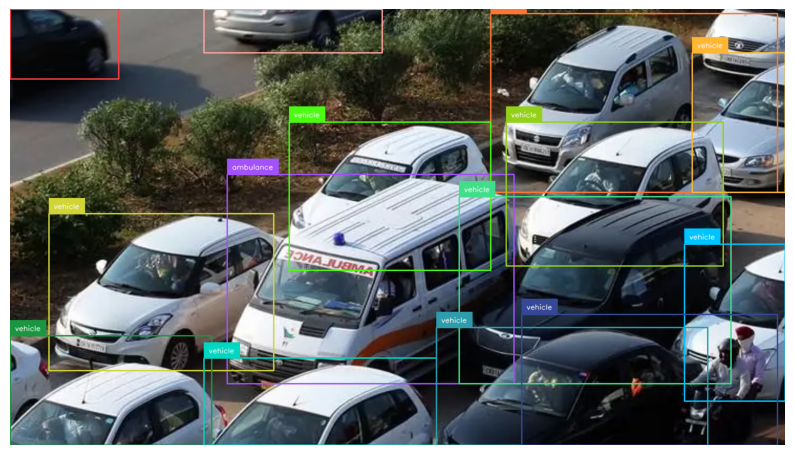

In [5]:
TEST_IMAGE = r"..\Dev1 pipeline\img with emergency.avif"
os.makedirs("dev2_feed", exist_ok=True)

if os.path.exists(TEST_IMAGE):
    if TEST_IMAGE.lower().endswith('.avif'):
        import pillow_avif
        image = np.array(Image.open(TEST_IMAGE).convert('RGB'))[:, :, ::-1].copy()
    else:
        image = cv2.imread(TEST_IMAGE)

    res, detections, labels = process_frame(image)
    
    # --- DEV 2 Integration Layer ---
    dev2_log = {
        "timestamp": time.time(),
        "normal_count": len([v for v in res if v['type'] == 'normal_vehicle']),
        "emergency_count": len([v for v in res if v['type'] == 'emergency_vehicle']),
        "details": res
    }
    
    log_path = "dev2_feed/latest_image_data.json"
    with open(log_path, "w") as f:
        json.dump(dev2_log, f, indent=2)
    
    print(f"🔥 DEV 2 Export Successful: {log_path}")
    print(f"📊 Counts: Normal={dev2_log['normal_count']}, Emergency={dev2_log['emergency_count']}")

    # Visualization
    if len(detections) > 0:
        scene = bounding_box_annotator.annotate(scene=image.copy(), detections=detections)
        scene = label_annotator.annotate(scene=scene, detections=detections, labels=labels)
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
else:
    print("File not found.")

## 🎥 Cell 3 — Process Video & Continuous Dev 2 Feed

Processes frames and updates the Dev 2 input file continuously.

In [6]:
VIDEO_PATH = r"..\Dev1 pipeline\153283-804933523_medium.mp4"
SAMPLE_INTERVAL = 8.0

if os.path.exists(VIDEO_PATH):
    cap = cv2.VideoCapture(VIDEO_PATH)
    fps = cap.get(cv2.CAP_PROP_FPS)
    step = int(fps * SAMPLE_INTERVAL)
    
    print(f"🎞️ Processing Video into Dev 2 Feed...")
    
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if idx % step == 0:
            res, dets, labels = process_frame(frame)
            
            # Update Dev 2 feed for THIS timestamp
            frame_data = {
                "time_offset": idx / fps,
                "normal_count": len([v for v in res if v['type'] == 'normal_vehicle']),
                "emergency_count": len([v for v in res if v['type'] == 'emergency_vehicle'])
            }
            
            log_file = f"dev2_feed/frame_{idx:05}.json"
            with open(log_file, "w") as f:
                json.dump(frame_data, f, indent=2)
                
            print(f"[Snapshot {idx}] Counts Exported: {frame_data['normal_count']} normal, {frame_data['emergency_count']} emergency")
            
        idx += 1
    
    cap.release()
    print("\n🏁 Video feed for Dev 2 is ready!")
else:
    print("Video not found.")

🎞️ Processing Video into Dev 2 Feed...
[Snapshot 0] Counts Exported: 10 normal, 0 emergency
[Snapshot 240] Counts Exported: 5 normal, 1 emergency
[Snapshot 480] Counts Exported: 3 normal, 0 emergency

🏁 Video feed for Dev 2 is ready!
